## Load in protein Data

In [3]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
# expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values
adata.obsm["X_umap"] = umap.values

This is way to label cells as CD8 interacting, tumor interacting or interacting with both.  Our hypothesis is that PMN-CD8 interactions, which are more common in patients who were non-responsive to therapy, suppress the immune system. Conversly PMN-tumor interactions may be predictive of PMN cells targeting the cancer. 

The output should be four groups
1. CD8 interacting
2. Tumor interacting
3. Both interacting
4. Neither interacting

Interacting will be considered 15 microns most typically. 


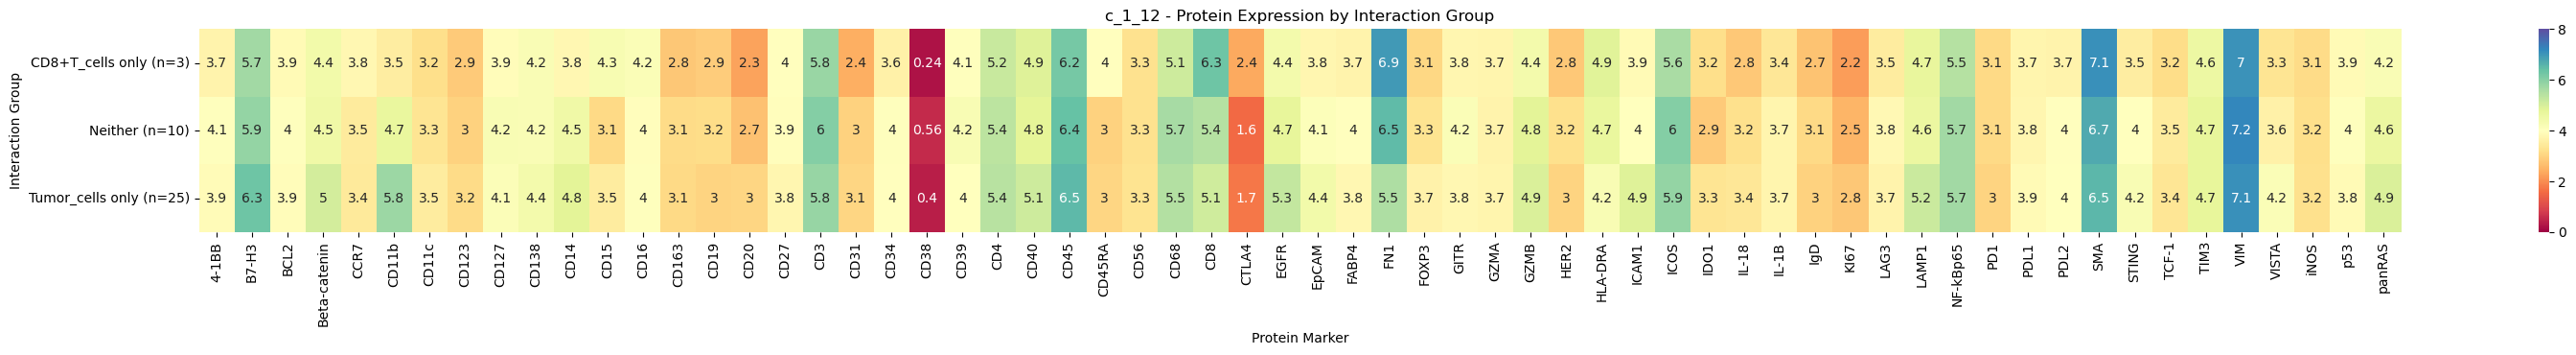

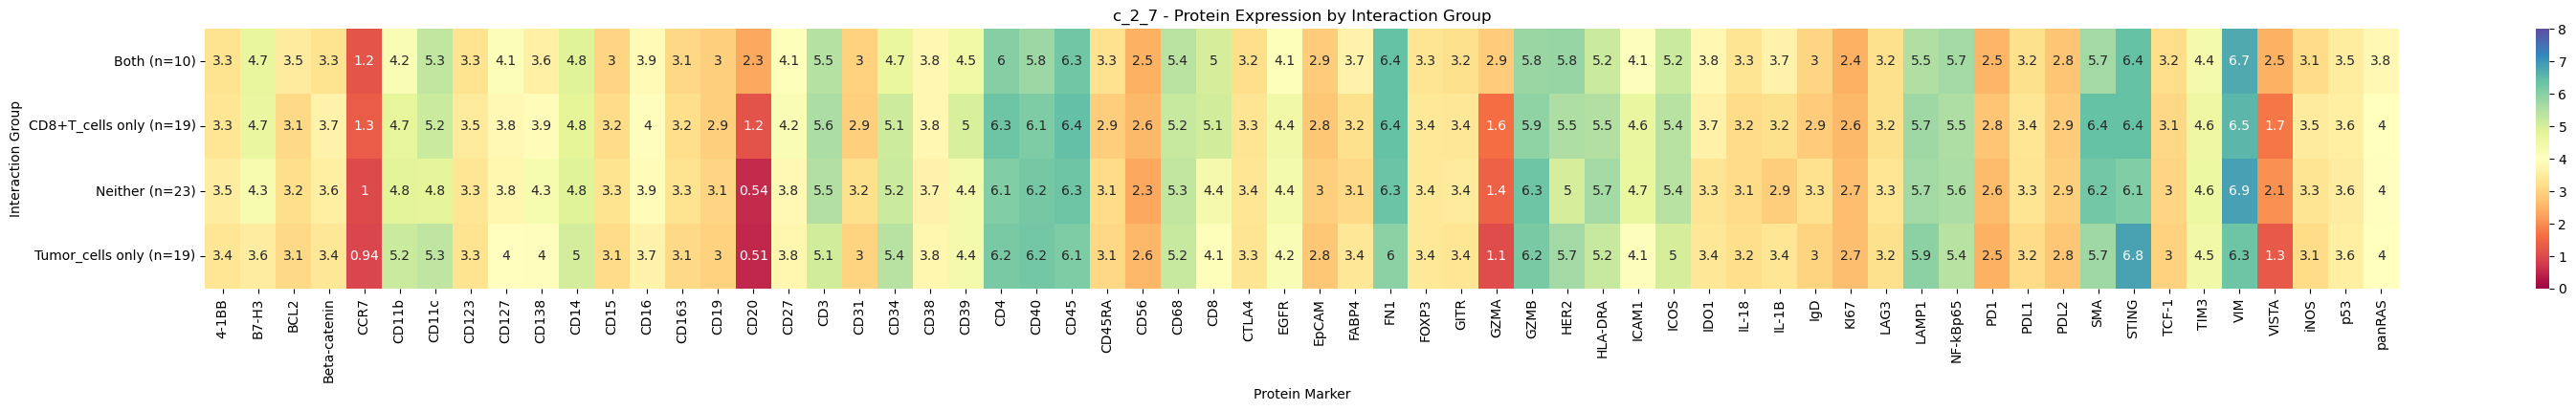

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import my_functions


def plot_grouped_protein_heatmap(adata, interaction_matrix, protein_layer=None,
                                  title="Protein Expression by Interaction Group",
                                  group_order=None, vmax=8):
    """
    Plots a heatmap of average protein expression across interaction groups,
    including cell counts in row labels.

    Parameters
    ----------
    adata : AnnData
        Annotated data object containing protein expression data (in `.X` or a `.layers[]` slot).

    interaction_matrix : pandas.DataFrame
        Output of get_interaction_status()["Interaction Matrix"], must have 'Interaction_Status'.

    protein_layer : str or None, optional
        If provided, uses adata.layers[protein_layer] for protein expression.
        If None, uses adata.X.

    title : str
        Title of the heatmap plot.

    group_order : list of str, optional
        Custom ordering of interaction groups. If None, groups will be sorted alphabetically.

    vmax : float, optional
        Max value for color scale (default: 8).

    Returns
    -------
    None
        Displays the heatmap.
    """
    # Align AnnData with interaction matrix
    adata_subset = adata[interaction_matrix.index].copy()
    adata_subset.obs['Interaction_Status'] = interaction_matrix['Interaction_Status']

    # Get expression matrix
    expr = adata_subset.layers[protein_layer] if protein_layer else adata_subset.X
    expr_df = pd.DataFrame(
        expr.toarray() if hasattr(expr, 'toarray') else expr,
        index=adata_subset.obs_names,
        columns=adata_subset.var_names
    )
    expr_df['Interaction_Status'] = adata_subset.obs['Interaction_Status']

    # Count cells per group
    group_counts = expr_df['Interaction_Status'].value_counts()

    # Group and average expression
    grouped_expr = expr_df.groupby('Interaction_Status').mean()

    # Rename rows to include counts
    new_index = [
        f"{group} (n={group_counts[group]})"
        for group in grouped_expr.index
    ]
    grouped_expr.index = new_index

    # Apply custom order (with counts)
    if group_order:
        # Map raw group names to their labeled form
        order_with_counts = [
            f"{g} (n={group_counts[g]})" for g in group_order if g in group_counts
        ]
        grouped_expr = grouped_expr.reindex(order_with_counts)
    else:
        grouped_expr = grouped_expr.sort_index()

    # Plot heatmap
    plt.figure(figsize=(max(10, len(grouped_expr.columns) * 0.5), len(grouped_expr) * 0.6 + 2))
    sns.heatmap(grouped_expr, cmap="Spectral", annot=True, vmin=0, vmax=vmax)
    plt.title(title)
    plt.ylabel('Interaction Group')
    plt.xlabel('Protein Marker')
    plt.tight_layout()
    plt.show()



# Sample 1:
sample_id="c_1_12"
distance_threshold=15
title=f"{sample_id} - Protein Expression by Interaction Group"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix,  title=title)

# Sample 2:
sample_id="c_2_7"
title=f"{sample_id} - Protein Expression by Interaction Group"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold=20)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix, title=title)
    

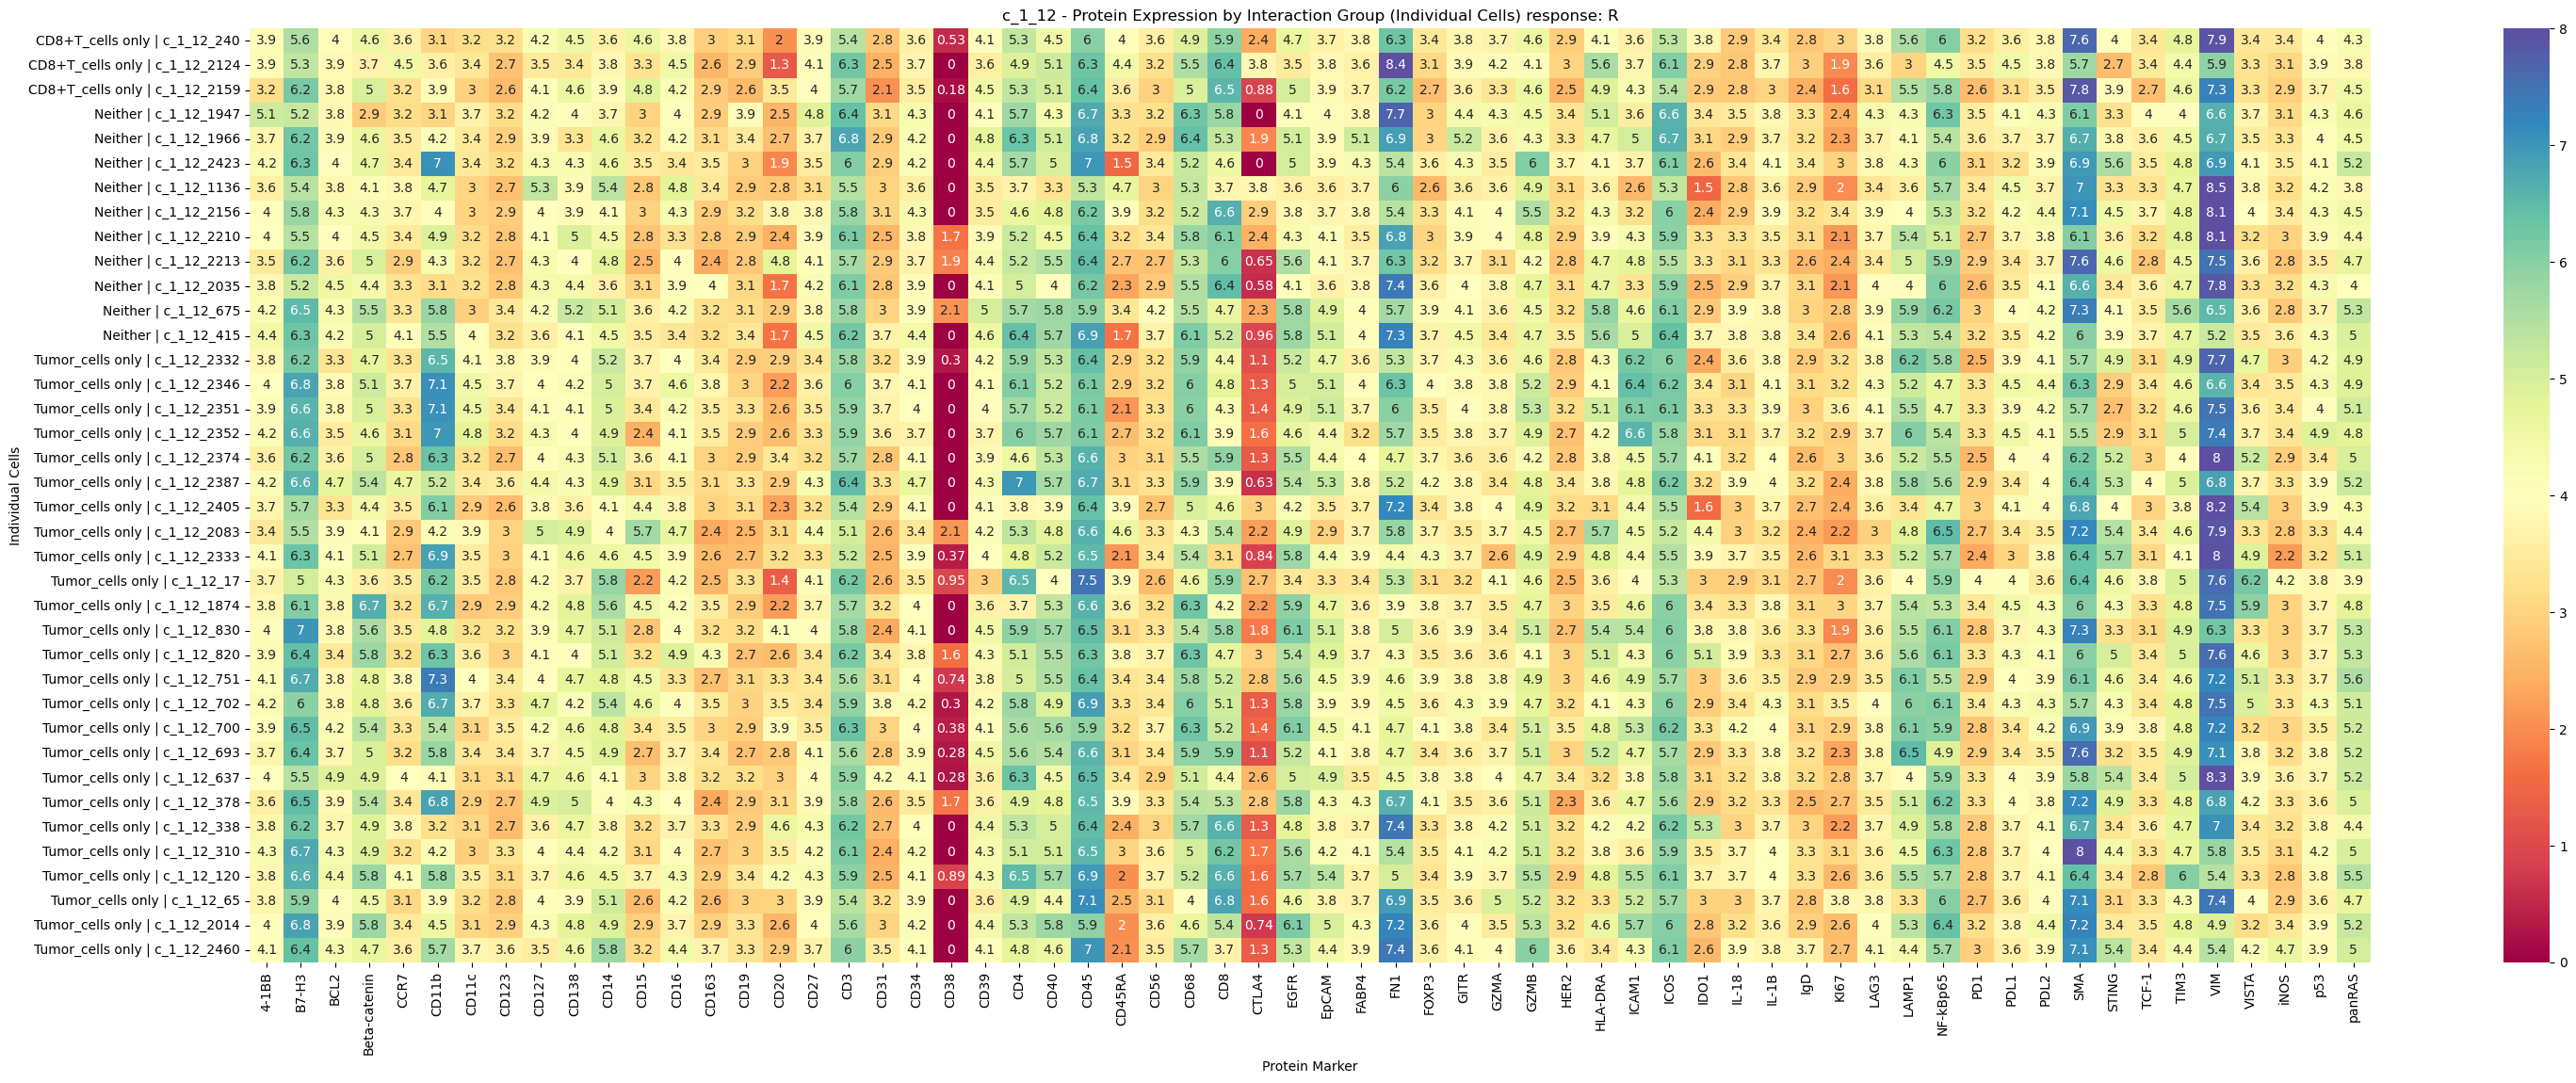

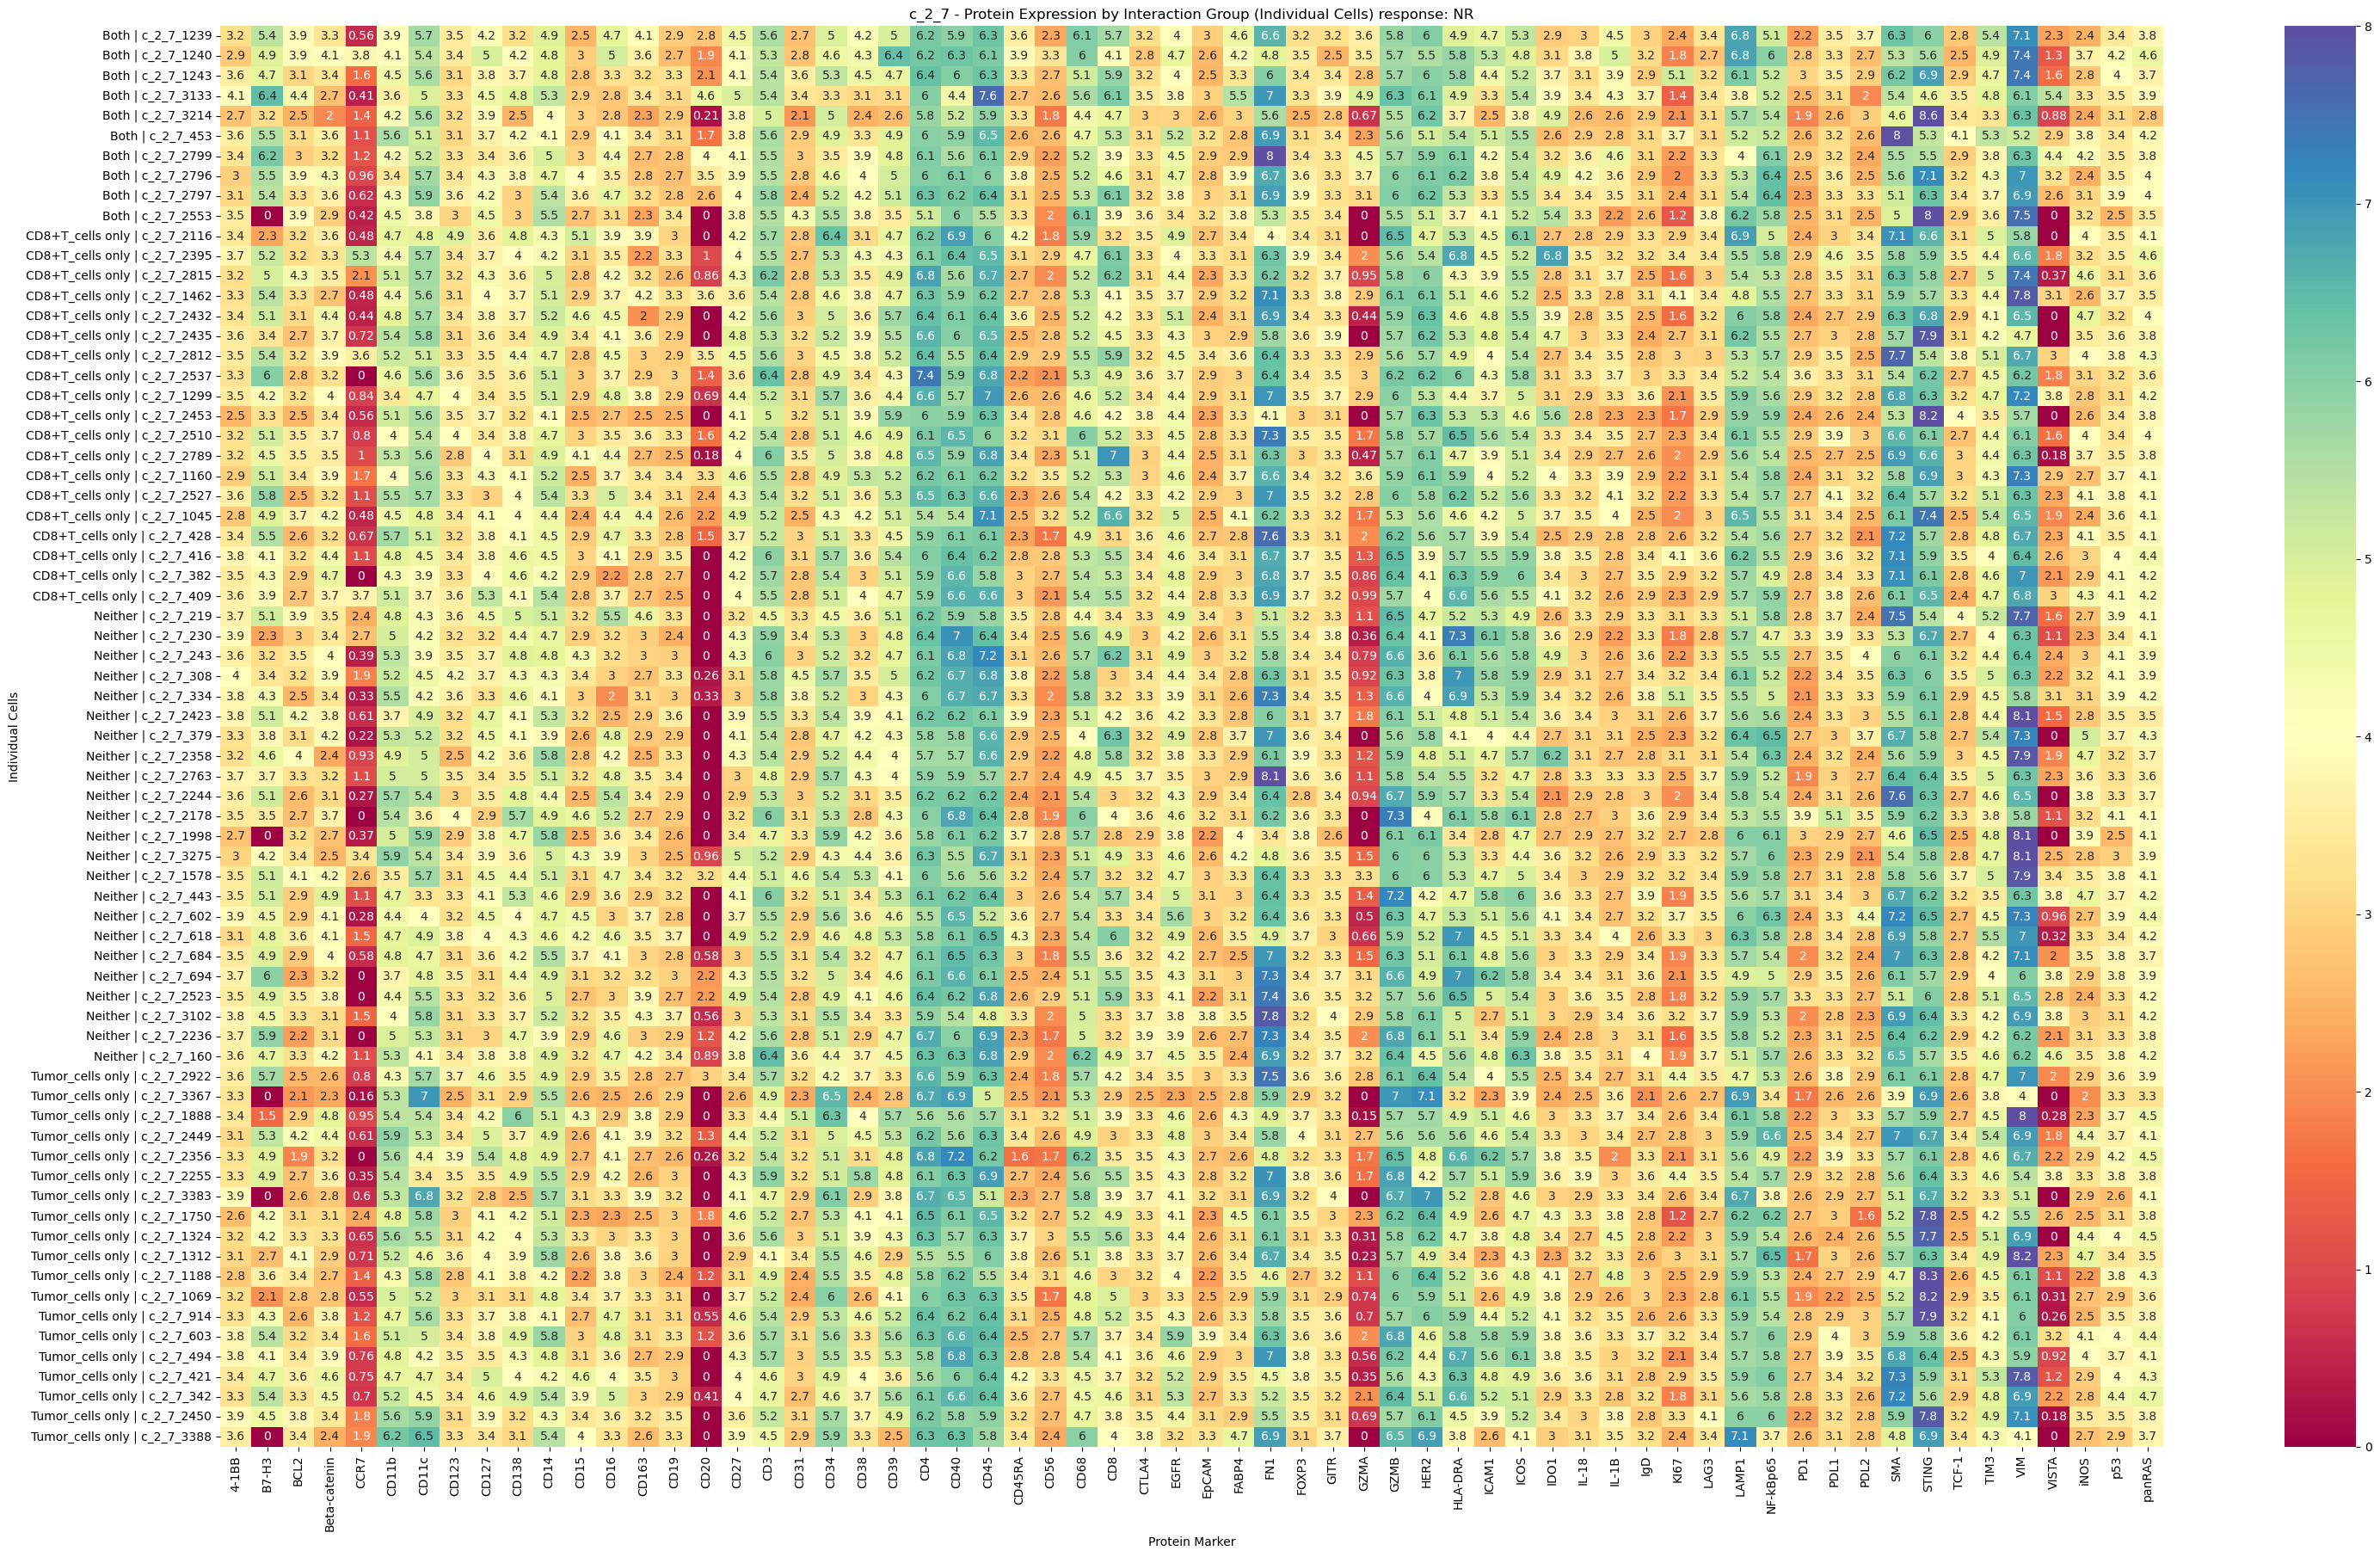

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import my_functions

def plot_grouped_protein_heatmap_individual(adata, interaction_matrix,sample_id, protein_layer=None,
                                             title="Protein Expression by Interaction Group (Individual Cells)",
                                             group_order=None, vmax=8):
    """
    Plots a heatmap of protein expression per cell, grouped by interaction status.

    Parameters
    ----------
    adata : AnnData
        Annotated data object containing protein expression data (in `.X` or a `.layers[]` slot).
    interaction_matrix : pandas.DataFrame
        Output of get_interaction_status()["Interaction Matrix"], must have 'Interaction_Status'.
    protein_layer : str or None, optional
        If provided, uses adata.layers[protein_layer] for protein expression.
        If None, uses adata.X.
    title : str
        Title of the heatmap plot.
    group_order : list of str, optional
        Custom ordering of interaction groups. If None, groups are sorted alphabetically.
    vmax : float, optional
        Max value for color scale (default: 8).
    Returns
    -------
    None
        Displays the heatmap.
    """
    # Align adata with interaction_matrix
    adata_subset = adata[interaction_matrix.index].copy()
    adata_subset.obs['Interaction_Status'] = interaction_matrix['Interaction_Status']

    # Get expression matrix
    expr = adata_subset.layers[protein_layer] if protein_layer else adata_subset.X
    expr_df = pd.DataFrame(
        expr.toarray() if hasattr(expr, 'toarray') else expr,
        index=adata_subset.obs_names,
        columns=adata_subset.var_names
    )

    # Response status
    response=my_functions.get_sample_info(adata,sample_id)["Response"]
    
    # Add interaction status as a column
    expr_df['Interaction_Status'] = adata_subset.obs['Interaction_Status']

    # Sort by group
    if group_order:
        expr_df['Interaction_Status'] = pd.Categorical(expr_df['Interaction_Status'], categories=group_order, ordered=True)
    expr_df = expr_df.sort_values("Interaction_Status")

    # Extract only expression columns
    expr_data = expr_df.drop(columns=["Interaction_Status"])

    # Create row labels (group name + cell ID)
    row_labels = [f"{group} | {cell_id}" for group, cell_id in zip(expr_df["Interaction_Status"], expr_df.index)]

    # Plot heatmap
    plt.figure(figsize=(max(10, len(expr_data.columns) * 0.5), len(expr_data) * 0.2 + 4))
    sns.heatmap(expr_data, cmap="Spectral", vmin=0, vmax=vmax, yticklabels=row_labels,annot=True,)
    plt.title(f"{title} response: {response}")
    plt.ylabel('Individual Cells')
    plt.xlabel('Protein Marker')
    plt.tight_layout()
    plt.show()

# Sample 1: Individual cell heatmap
sample_id = "c_1_12"
distance_threshold = 15
title = f"{sample_id} - Protein Expression by Interaction Group (Individual Cells)"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap_individual(adata, interaction_matrix, sample_id,title=title)

# Sample 2: Individual cell heatmap
sample_id = "c_2_7"
distance_threshold = 20
title = f"{sample_id} - Protein Expression by Interaction Group (Individual Cells)"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap_individual(adata, interaction_matrix, sample_id, title=title)

#### Failed Attempt to improve heatmap

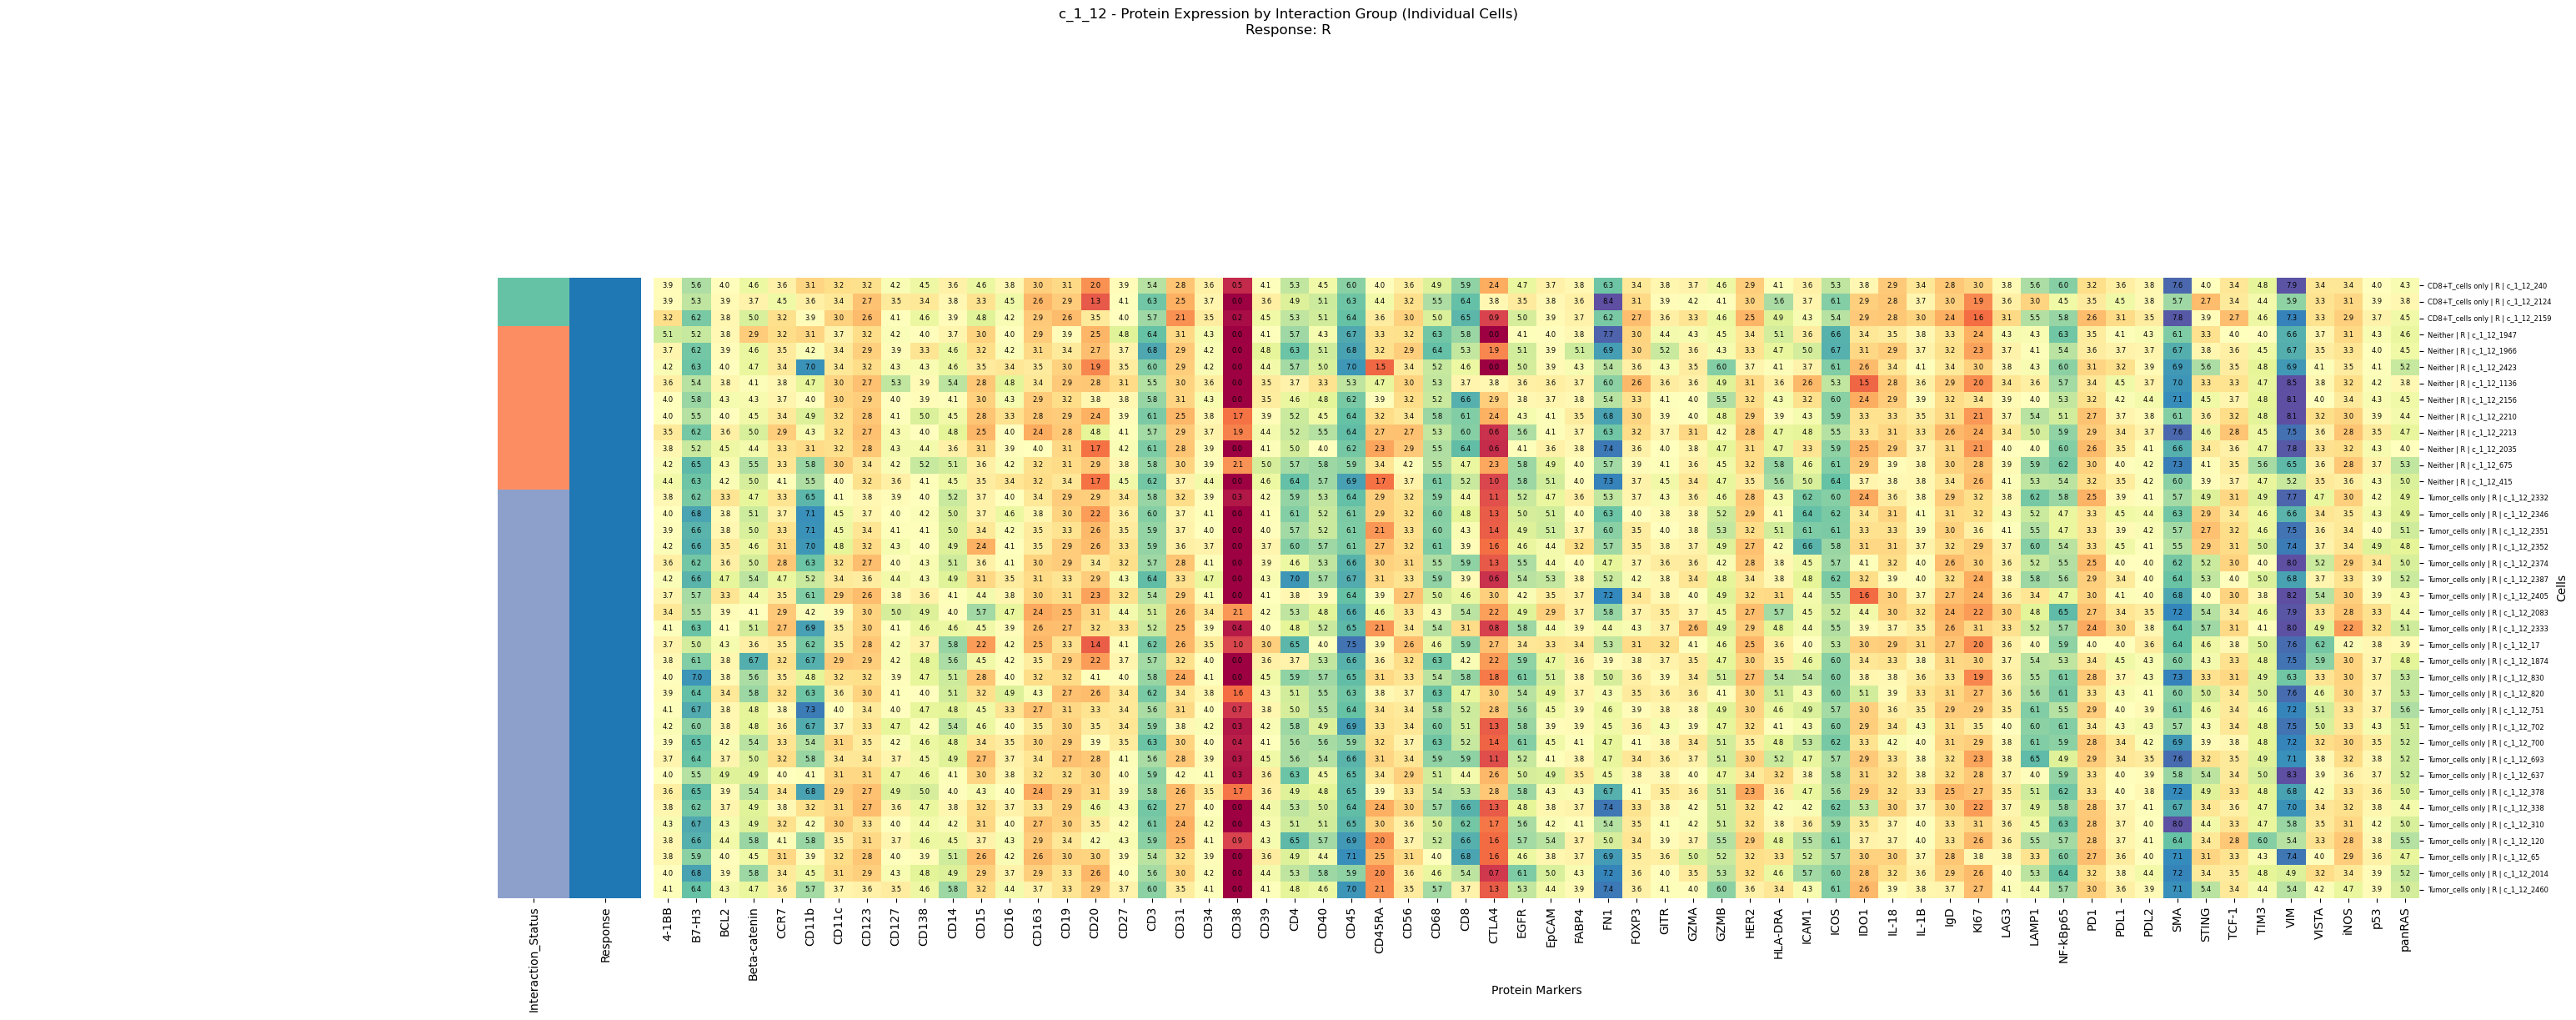

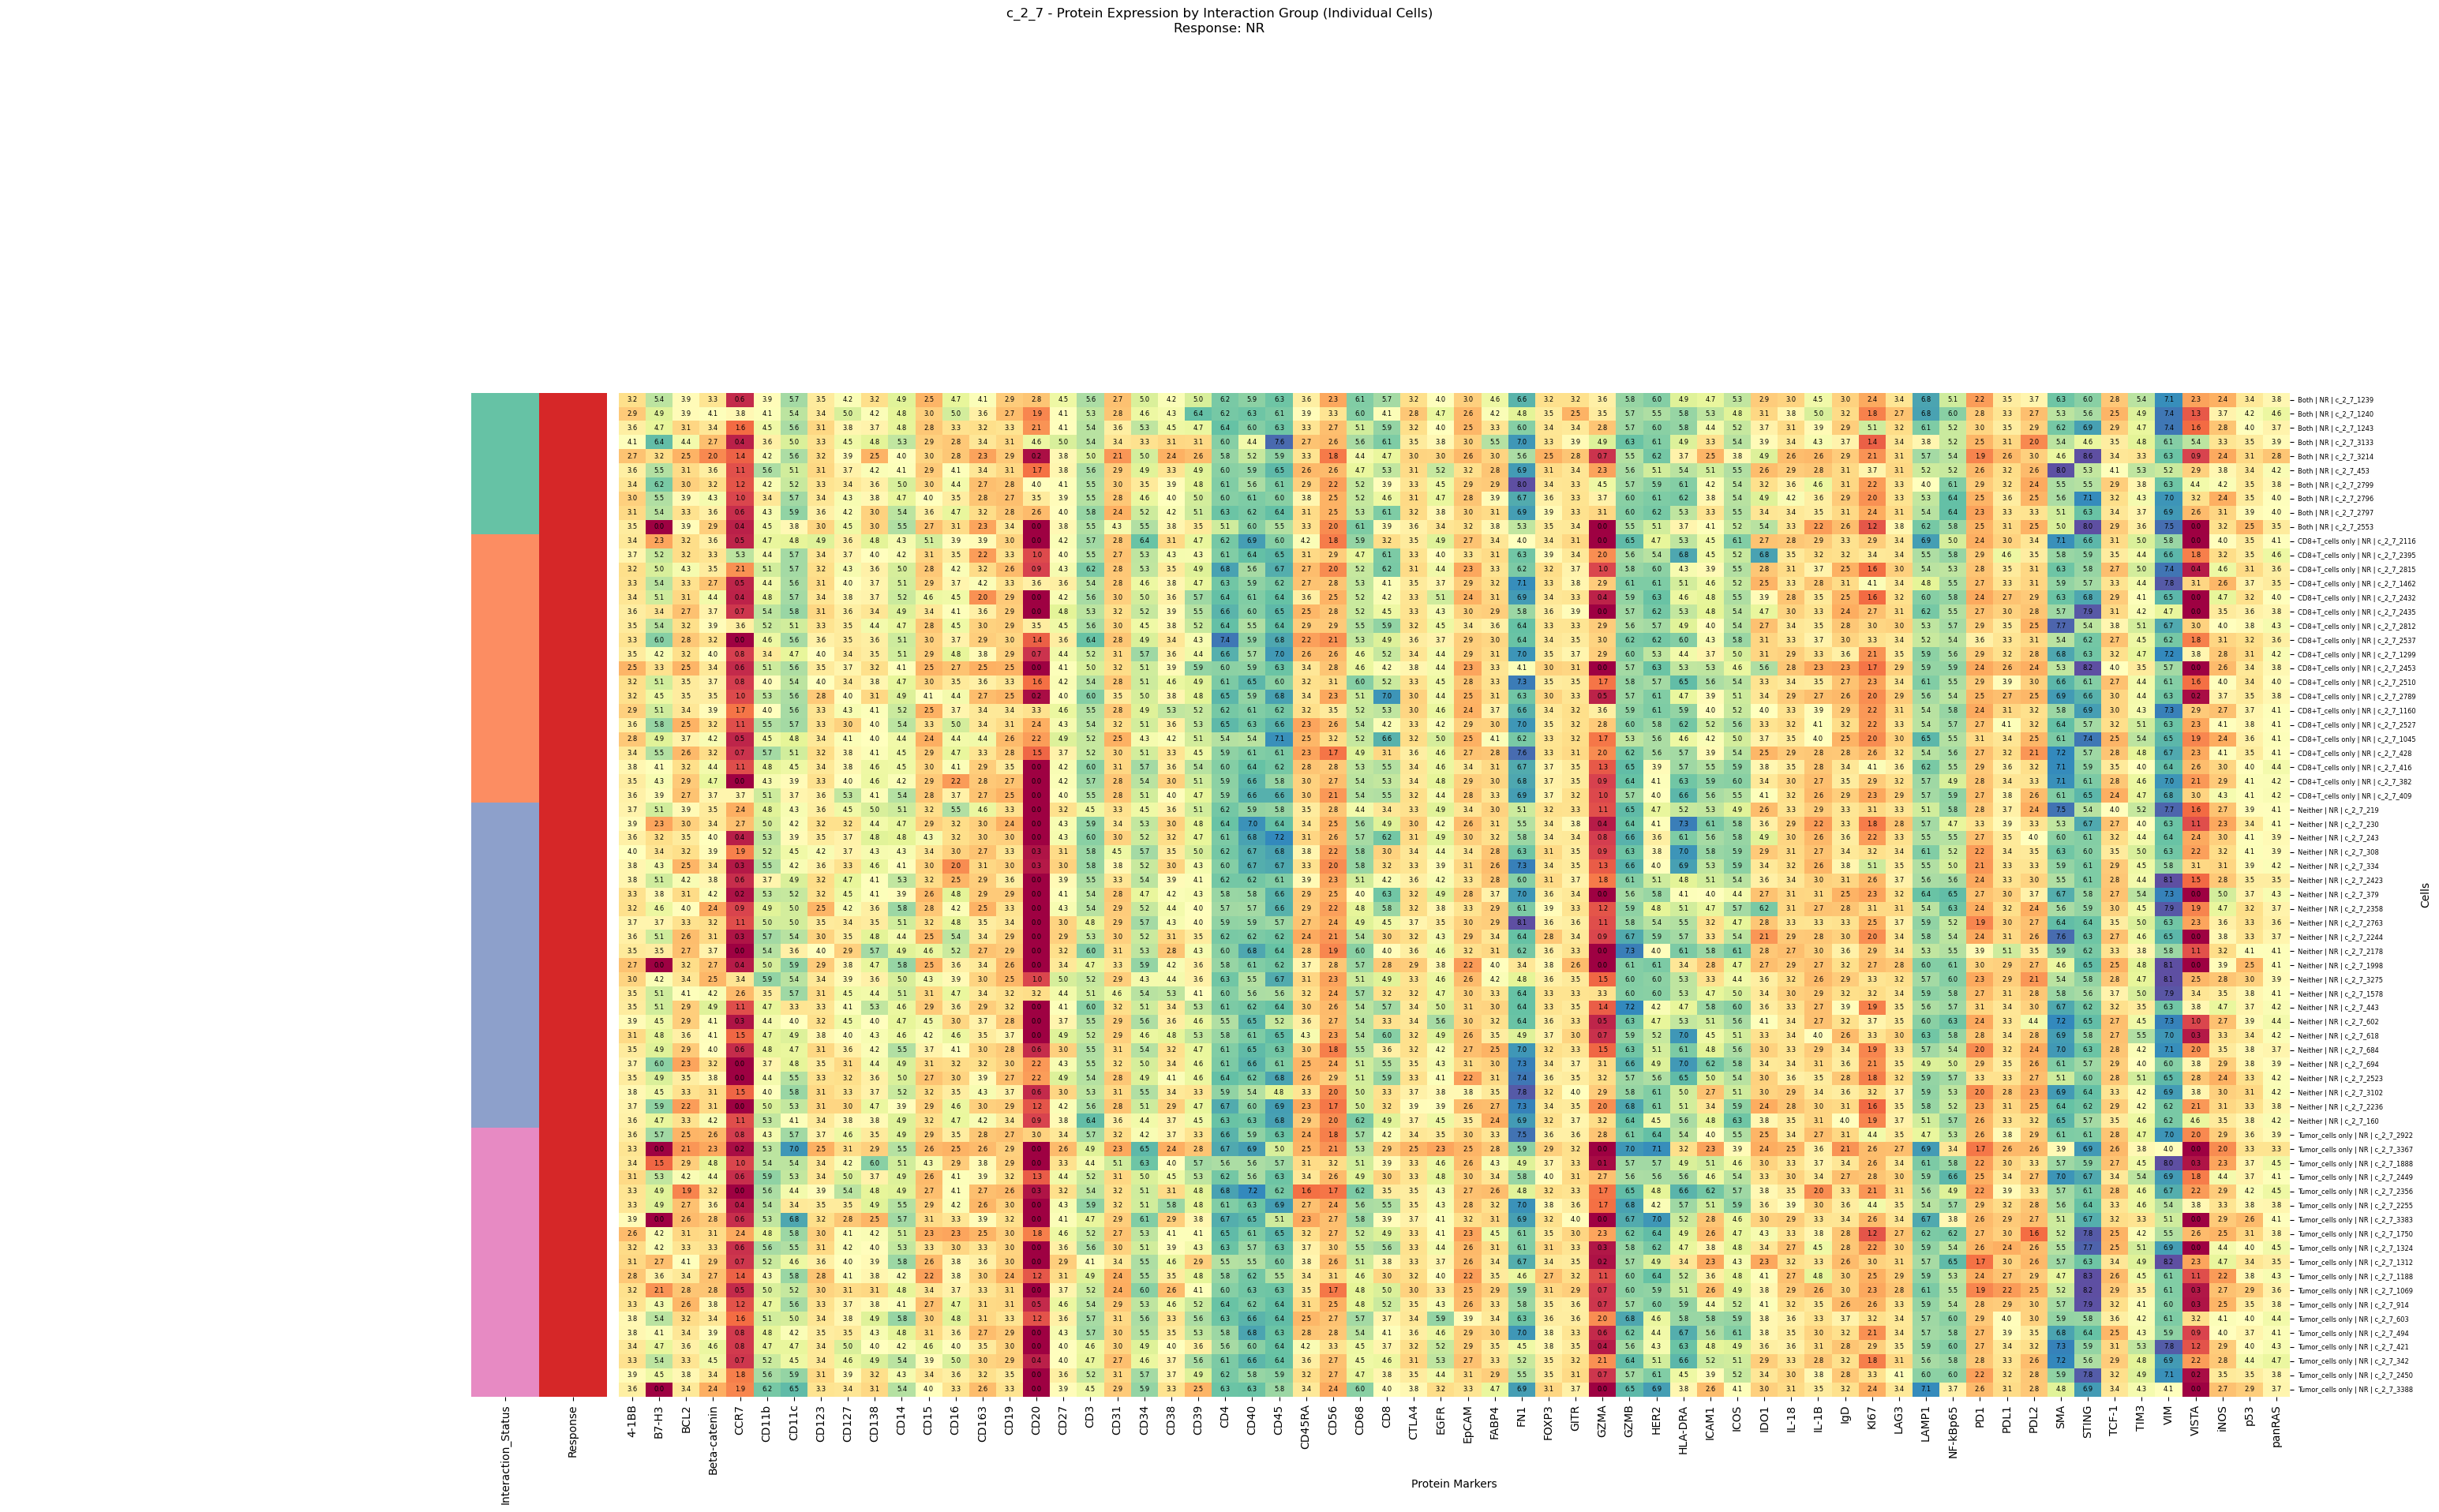

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_grouped_protein_heatmap_individual(
    adata,
    interaction_matrix,
    sample_id,
    protein_layer=None,
    title="Protein Expression by Interaction Group (Individual Cells)",
    group_order=None,
    vmax=8,
):
    """
    Plots a heatmap of protein expression per cell, grouped by interaction status,
    and shows response and interaction status as metadata columns.
    """
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    # Subset to relevant cells and store interaction status
    adata_subset = adata[interaction_matrix.index].copy()
    adata_subset.obs['Interaction_Status'] = interaction_matrix['Interaction_Status']

    # Expression matrix
    expr = adata_subset.layers[protein_layer] if protein_layer else adata_subset.X
    expr_df = pd.DataFrame(
        expr.toarray() if hasattr(expr, 'toarray') else expr,
        index=adata_subset.obs_names,
        columns=adata_subset.var_names
    )

    # Add metadata columns
    expr_df['Interaction_Status'] = adata_subset.obs['Interaction_Status']
    response = my_functions.get_sample_info(adata, sample_id)["Response"]
    expr_df['Response'] = response

    # Optional: order by group
    if group_order:
        expr_df['Interaction_Status'] = pd.Categorical(expr_df['Interaction_Status'], categories=group_order, ordered=True)
    expr_df = expr_df.sort_values(['Interaction_Status'])

    # Extract expression data and annotations
    expr_data = expr_df.drop(columns=["Interaction_Status", "Response"])
    row_colors = pd.DataFrame({
        "Interaction_Status": expr_df["Interaction_Status"],
        "Response": expr_df["Response"]
    }, index=expr_df.index)

    # Define color palettes
    interaction_palette = sns.color_palette("Set2", n_colors=row_colors["Interaction_Status"].nunique())
    response_palette = {"R": "#1f77b4", "NR": "#d62728"}

    row_color_dict = {
        "Interaction_Status": dict(zip(row_colors["Interaction_Status"].unique(), interaction_palette)),
        "Response": response_palette
    }

    # Map colors
    row_colors_mapped = row_colors.apply(lambda col: col.map(row_color_dict[col.name]))

    # Construct labels to show on the right
    custom_labels = [
        f"{interaction} | {resp} | {cell_id}"
        for interaction, resp, cell_id in zip(
            expr_df["Interaction_Status"], expr_df["Response"], expr_df.index
        )
    ]

    # Plot clustermap
    g = sns.clustermap(
        expr_data,
        row_colors=row_colors_mapped,
        cmap="Spectral",
        vmin=0,
        vmax=vmax,
        figsize=(max(10, len(expr_data.columns) * 0.5), len(expr_data) * 0.2 + 4),
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
        cbar_pos=None
    )

    # Set row labels manually to the right
    g.ax_heatmap.set_yticks([x + 0.5 for x in range(expr_data.shape[0])])
    g.ax_heatmap.set_yticklabels(custom_labels, fontsize=6)
    g.ax_heatmap.yaxis.tick_right()
    g.ax_heatmap.yaxis.set_label_position('right')
    g.ax_heatmap.tick_params(axis='y', left=False, labelleft=False, labelright=True)

    # Add numerical annotations inside heatmap
    for i in range(expr_data.shape[0]):
        for j in range(expr_data.shape[1]):
            val = expr_data.iloc[i, j]
            g.ax_heatmap.text(
                j + 0.5, i + 0.5, f"{val:.1f}",
                ha='center', va='center', fontsize=6, color='black'
            )

    g.fig.suptitle(f"{title}\nResponse: {response}", y=1.05)
    g.ax_heatmap.set_ylabel("Cells")
    g.ax_heatmap.set_xlabel("Protein Markers")
    plt.tight_layout()
    plt.show()


# Sample 1: Individual cell heatmap
sample_id = "c_1_12"
distance_threshold = 15
title = f"{sample_id} - Protein Expression by Interaction Group (Individual Cells)"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap_individual(adata, interaction_matrix, sample_id,title=title)

# Sample 2: Individual cell heatmap
sample_id = "c_2_7"
distance_threshold = 20
title = f"{sample_id} - Protein Expression by Interaction Group (Individual Cells)"
result = my_functions.get_interaction_status(adata, sample_id, distance_threshold)
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap_individual(adata, interaction_matrix, sample_id, title=title)

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_grouped_protein_heatmap_individual(
    adata,
    interaction_matrix,
    protein_layer=None,
    title="Protein Expression by Interaction Group (Individual Cells)",
    metadata_cols=None,
    vmax=8
):
    """
    Plots a heatmap of protein expression for individual cells, with metadata annotations.

    Parameters
    ----------
    adata : AnnData
        Annotated data object containing protein expression data.

    interaction_matrix : pd.DataFrame
        Must include an 'Interaction_Status' column for labeling.

    protein_layer : str or None
        Use adata.layers[protein_layer] if specified; else use adata.X.

    title : str
        Plot title.

    metadata_cols : list of str or None
        Additional non-numeric .obs columns to annotate the heatmap rows.

    vmax : float
        Max value for color scale.

    Returns
    -------
    None
        Displays the heatmap.
    """
    # Align AnnData with interaction matrix
    adata_subset = adata[interaction_matrix.index].copy()
    adata_subset.obs['Interaction_Status'] = interaction_matrix['Interaction_Status']

    # Get expression matrix
    expr = adata_subset.layers[protein_layer] if protein_layer else adata_subset.X
    expr_df = pd.DataFrame(
        expr.toarray() if hasattr(expr, 'toarray') else expr,
        index=adata_subset.obs_names,
        columns=adata_subset.var_names
    )

    # Attach annotations
    annotations = pd.DataFrame(index=adata_subset.obs_names)
    annotations["Interaction_Status"] = adata_subset.obs["Interaction_Status"]
    if metadata_cols:
        for col in metadata_cols:
            if col in adata_subset.obs:
                annotations[col] = adata_subset.obs[col]

    # Convert categorical annotations to color palettes
    col_colors = {}
    for col in annotations.columns:
        unique_vals = annotations[col].unique()
        palette = sns.color_palette("Set2", n_colors=len(unique_vals))
        lut = dict(zip(unique_vals, palette))
        col_colors[col] = annotations[col].map(lut)

    row_colors = pd.concat(col_colors.values(), axis=1)
    row_colors.columns = col_colors.keys()

    # Plot heatmap
    sns.clustermap(
        expr_df,
        row_colors=row_colors,
        figsize=(max(10, expr_df.shape[1] * 0.4), max(8, expr_df.shape[0] * 0.1)),
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        col_cluster=False,
        row_cluster=False
    )
    plt.suptitle(title, y=1.02)
    plt.show()


In [27]:
import pandas as pd

responders = []
non_responders = []

for i in range(1, 4):
    for j in range(1, 26):
        sample_id = f"c_{i}_{j}"
        
        try:
            # Get response type: "R" or "NR"
            response = my_functions.get_sample_info(adata, sample_id)["Response"]
            
            # Get interaction matrix
            result = my_functions.get_interaction_status(adata, sample_id, distance_threshold=20)
            interaction_matrix = result["Interaction Matrix"].copy()

            # Add sample metadata
            interaction_matrix["Sample_ID"] = sample_id
            interaction_matrix["i"] = i
            interaction_matrix["j"] = j
            interaction_matrix["Response"] = response

            # Append to the appropriate list
            if response == "R":
                responders.append(interaction_matrix)
            elif response == "NR":
                non_responders.append(interaction_matrix)
            else:
                print(f"Unknown response label '{response}' in {sample_id}")

        except Exception as e:
            print(f"Skipping {sample_id} due to error: {e}")

# Combine into DataFrames
responders_df = pd.concat(responders).reset_index().rename(columns={"index": "PMN_Cell_ID"})
non_responders_df = pd.concat(non_responders).reset_index().rename(columns={"index": "PMN_Cell_ID"})


Unknown response label 'NA' in c_3_1
Unknown response label 'NA' in c_3_2
Unknown response label 'NA' in c_3_21
Unknown response label 'NA' in c_3_22
Unknown response label 'NA' in c_3_23
Unknown response label 'NA' in c_3_24
Unknown response label 'NA' in c_3_25


## CD8 Cell Comparison 

In [20]:
# Sample 1:
sample_id="c_1_18"
distance_threshold=15
title=f"{sample_id} - CD8 Protein Expression by Interaction Group"
result = my_functions.get_interaction_status_v2(adata,sample_id, 15, "CD8+T_cells", cell_type_1="Neutrophil",cell_type_2="Tumor_cells")
interaction_matrix = result["Interaction Matrix"]
display(result["Interaction Matrix"])
plot_grouped_protein_heatmap(adata, interaction_matrix,  title=title)

# Sample 2:
sample_id="c_1_22"
title=f"{sample_id} - CD8 Protein Expression by Interaction Group"
result = my_functions.get_interaction_status_v2(adata,sample_id, 15, "CD8+T_cells", cell_type_1="Neutrophil",cell_type_2="Tumor_cells")
interaction_matrix = result["Interaction Matrix"]
plot_grouped_protein_heatmap(adata, interaction_matrix, title=title)

,Neutrophil Interacting,Tumor_cells Interacting,Interaction_Status
c_1_18_12,True,False,Neutrophil only
c_1_18_14,True,False,Neutrophil only
c_1_18_41,False,False,Neither
c_1_18_150,False,False,Neither
c_1_18_203,False,False,Neither
...,...,...,...
c_1_18_5070,False,False,Neither
c_1_18_5081,False,False,Neither
c_1_18_5096,False,False,Neither
c_1_18_5101,False,False,Neither


NameError: name 'plot_grouped_protein_heatmap' is not defined

### CD8 Entire Data Set Test (Other DataSets Can be used as well)

This script reverses the attempt I made with Neutrophils ealier to determine if CD8 colocalization impacts gene expression. PMN cells often are not the best markers of gene expression so this looks at the CD8 cells (1) catorogies them into groups of cellular interaction (2) Plots that interaction to determine if it is influenced by PMN colocalization or response status. If we can find some genetic markers than that may allow for targeting of particular ligand interactions. 

Sample c_1_1 complete
Sample c_1_2 complete
Sample c_1_3 complete
Sample c_1_4 complete
Sample c_1_5 complete
Sample c_1_6 complete
Sample c_1_7 complete
Sample c_1_8 complete
Sample c_1_9 complete
Sample c_1_10 complete
Sample c_1_11 complete


,Interaction_Status,4-1BB,B7-H3,BCL2,Beta-catenin,CCR7,CD11b,CD11c,CD123,CD127,...,STING,TCF-1,TIM3,VIM,VISTA,iNOS,p53,panRAS,sample_id,responder_status
0,Neither,3.040133,6.385096,3.144412,3.542479,2.908272,4.076287,2.659136,2.503499,4.686169,...,6.527398,2.715025,4.020678,7.167840,5.648559,3.096606,3.283275,3.688865,c_1_1,R
1,Tumor_cells only,3.495836,6.325650,3.385627,3.390256,2.837718,4.075458,2.821821,2.912704,4.410068,...,6.700407,3.074126,3.917105,7.071315,5.401182,3.072350,3.426408,3.930785,c_1_1,R
2,Neither,3.858163,1.275941,2.990282,4.129375,2.820692,3.907012,3.962382,3.617426,4.272909,...,3.967220,2.388236,4.476053,7.247613,0.873075,3.491714,3.579477,3.895254,c_1_3,R
3,Tumor_cells only,4.224112,0.000000,4.046878,3.187887,2.705147,4.712954,5.013419,3.893406,3.576024,...,2.273612,3.243796,4.660715,7.177504,0.000000,2.861596,3.421396,4.428748,c_1_3,R
4,Neither,3.938065,3.259770,3.258702,3.576665,3.698775,4.399636,3.134562,3.355220,4.378001,...,4.339130,3.190998,4.926352,7.702774,2.846135,3.835616,3.545591,4.294194,c_1_4,R
5,Tumor_cells only,3.663299,2.746675,3.585310,3.468614,3.441259,4.695293,3.336440,3.226385,4.375521,...,4.395707,3.217703,4.935319,7.836381,3.000191,5.197883,3.549016,4.034165,c_1_4,R
6,CD8+T_cells only,2.714911,0.065482,3.281382,3.074518,2.584626,7.341206,2.542693,2.656980,4.419745,...,1.535671,2.837489,3.676115,7.950522,0.000000,1.697249,2.881813,4.625535,c_1_5,R
7,Neither,2.470090,2.869851,3.438957,3.569740,2.805512,6.083059,3.355365,3.211426,4.458317,...,3.271190,3.087158,4.119127,7.908848,0.000000,2.366503,2.832373,4.521362,c_1_5,R
8,Tumor_cells only,2.144528,1.405992,3.234897,3.818930,2.762769,6.780221,2.864280,3.050882,4.527700,...,1.414883,2.894366,3.930234,8.053159,0.000000,2.073033,2.674558,4.723954,c_1_5,R
9,Neither,3.438395,6.396503,3.287785,3.161082,2.763926,3.486200,2.629990,2.792342,3.988324,...,5.704343,3.098583,3.848393,6.606223,5.687693,3.386001,3.707765,3.667097,c_1_6,R


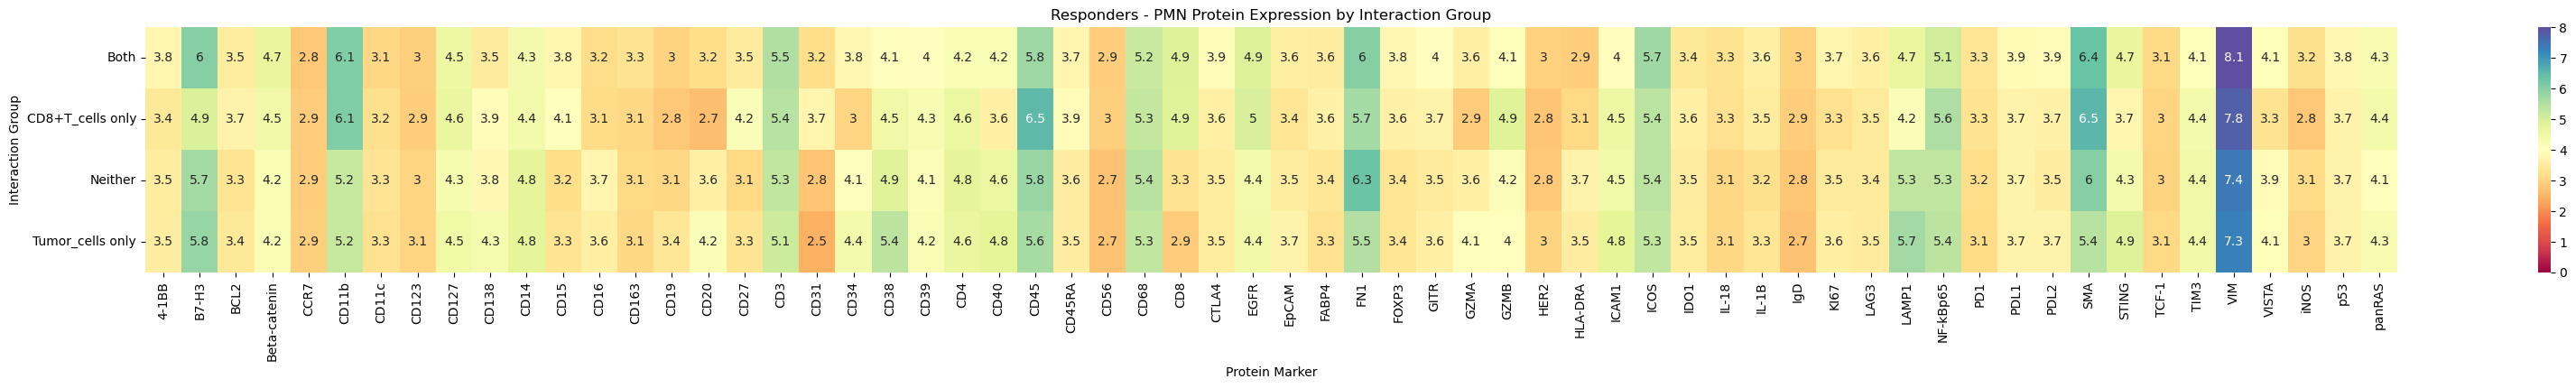

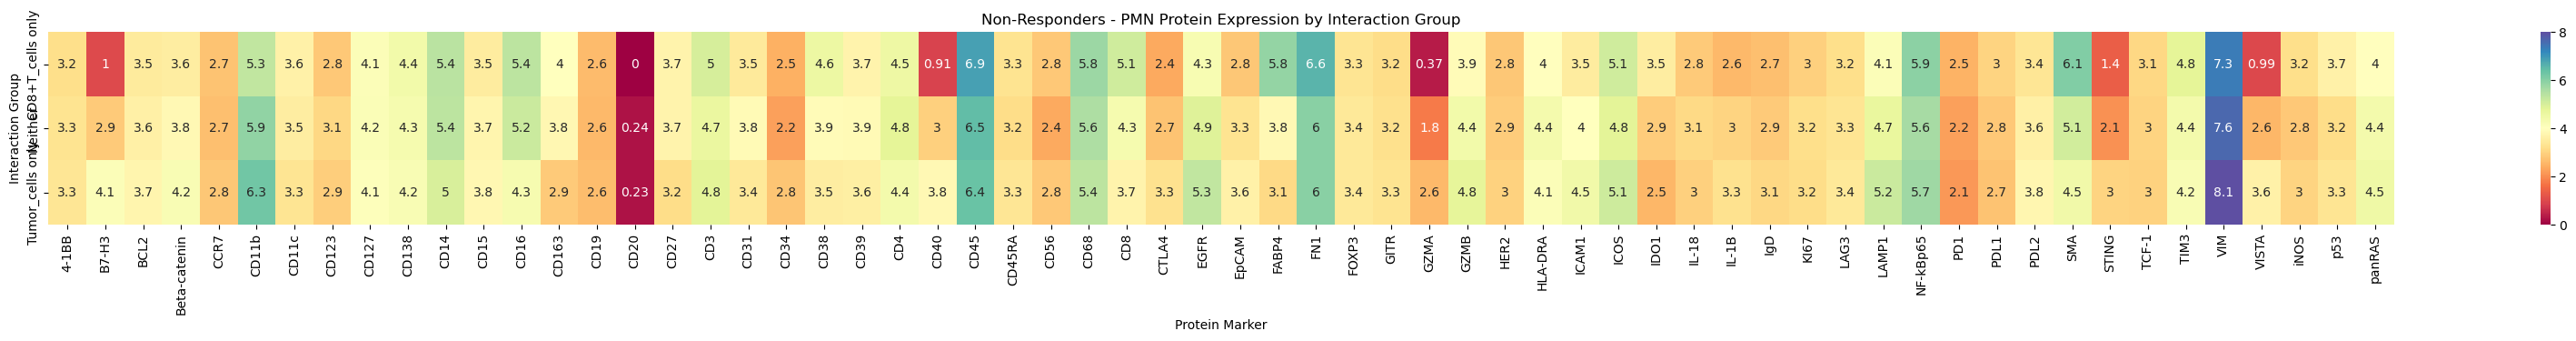

In [40]:
import my_functions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Initialize storage
responder_dfs = []# Initialize OUTSIDE the loop
nonresponder_dfs = []
combined_sample_avg = []  

# Parameters
distance_threshold = 15
target_cell_type = "Neutrophils"
cell_type_1 = "CD8+T_cells"
cell_type_2 = "Tumor_cells"

for i in range(1, 2):  # c_1_*, c_2_*, c_3_*
    for j in range(1, 12):  # c_*_1 to c_*_25
        sample_id = f"c_{i}_{j}"
        try:
            responder_status = my_functions.get_sample_info(adata, sample_id)['Response']  # 'R' or 'NR'

            # Try to extract the sample subset
            adata_sample = adata[adata.obs.cell_ID.str.contains(sample_id)].copy() #adata[adata.obs['sample'] == sample_id]  # Adjust key if needed

            result = my_functions.get_interaction_status_v2(
                adata_sample,
                sample_id,
                distance_threshold,
                target_cell_type,
                cell_type_1=cell_type_1
                ,cell_type_2=cell_type_2
            )
            interaction_matrix = result["Interaction Matrix"]

            # Extract protein expression matrix
            expr = adata_sample.X  # Or use .layers['protein'] if applicable
            expr_df = pd.DataFrame(
                expr.toarray() if hasattr(expr, 'toarray') else expr,
                index=adata_sample.obs_names,
                columns=adata_sample.var_names
            )
            expr_df['Interaction_Status'] = interaction_matrix['Interaction_Status']

            #display(interaction_matrix['Interaction_Status'])
            sample_avg=expr_df.groupby('Interaction_Status').mean()
            sample_avg['sample_id']=sample_id
            sample_avg['responder_status']=responder_status

            # Initalize Group Matrices 
            combined_sample_avg.append(sample_avg)  # Append to list

            # Append to appropriate list
            if responder_status == 'R':
                responder_dfs.append(expr_df)
            elif responder_status == 'NR':
                nonresponder_dfs.append(expr_df)

            #Prints Status to Track
            print(f"Sample c_{i}_{j} complete")
            
        except Exception as e:
            print(f"Skipping sample {sample_id}: {e}")
            continue

combined_sample_avg = pd.concat(combined_sample_avg).reset_index()
display(combined_sample_avg)

# Combine all samples by group
responder_combined = pd.concat(responder_dfs)
nonresponder_combined = pd.concat(nonresponder_dfs)

# Function to plot from combined df
def plot_grouped_heatmap_from_df(expr_df, title, vmax=8):
    group_counts = expr_df['Interaction_Status'].value_counts()
    grouped_expr = expr_df.groupby('Interaction_Status').mean()
   # grouped_expr.index = [f"{g} (n={group_counts[g]})" for g in grouped_expr.index]
    grouped_expr = grouped_expr.sort_index()
    plt.figure(figsize=(max(10, len(grouped_expr.columns) * 0.5+2), len(grouped_expr) * 0.6 + 2))
    sns.heatmap(grouped_expr, cmap="Spectral", annot=True, vmin=0, vmax=vmax)
    plt.title(title)
    plt.ylabel('Interaction Group')
    plt.xlabel('Protein Marker')
    plt.tight_layout()
    plt.show()

# Plot for responders
plot_grouped_heatmap_from_df(responder_combined, title="Responders - PMN Protein Expression by Interaction Group")

# Plot for non-responders
plot_grouped_heatmap_from_df(nonresponder_combined, title="Non-Responders - PMN Protein Expression by Interaction Group")

In [39]:
display(combined_sample_avg.tail(10))


,4-1BB,B7-H3,BCL2,Beta-catenin,CCR7,CD11b,CD11c,CD123,CD127,CD138,...,STING,TCF-1,TIM3,VIM,VISTA,iNOS,p53,panRAS,sample_id,responder_status
Interaction_Status,,,,,,,,,,,,,,,,,,,,,
Neither,3.040133,6.385096,3.144412,3.542479,2.908272,4.076287,2.659136,2.503499,4.686169,4.894191,...,6.527398,2.715025,4.020678,7.167840,5.648559,3.096606,3.283275,3.688865,c_1_1,R
Tumor_cells only,3.495836,6.325650,3.385627,3.390256,2.837718,4.075458,2.821821,2.912704,4.410068,5.037558,...,6.700407,3.074126,3.917105,7.071315,5.401182,3.072350,3.426408,3.930785,c_1_1,R


### Attempt 2 at CD8 Mapping


Seems like I accidently deleted the last attempt



In [ ]:


def get_interaction_status_v2(adata,sample_id, distance_threshold, target_cell_type, cell_type_1="Neutrophil",cell_type_2="NA"):
    """
    Find whether a particular cell group is neitherboring two other cell groups
    
    Parameters
    ----------
    adata : AnnData
        The annotated data object containing spatial transcriptomics or single-cell data.
    sample_id : str
        Identifier for the sample to analyze within `adata`.
    distance_threshold : float
        Distance in microns to define interaction (e.g., 20 means a cell is interacting if it's ≤ 20 microns away).
    cell_type_1 : str, optional
        First target cell type to assess interaction with (default is "CD8+T_cells").
    cell_type_2 : str, optional
        Second target cell type to assess interaction with (default is "Tumor_cells").
    Returns
    -------
    dict
        A dictionary with one key:
        - "Interaction Matrix": pandas.DataFrame with:
            * Boolean columns: 
              - '{cell_type_1} Interacting'
              - '{cell_type_2} Interacting'
            * Categorical column:
              - 'Interaction_Status' (values: 'Both', '{cell_type_1} only', '{cell_type_2} only', 'Neither')
    """
    import pandas as pd
    
    # Load distance matrices
    results_CD8 = nearest_cells_of_particular_type_v2(adata,sample_id,target_cell_type, cell_type_1)["Distance Matrix"]
    results_Tumor = nearest_cells_of_particular_type_v2(adata,sample_id,target_cell_type, cell_type_2)["Distance Matrix"]
    
    # Set interaction threshold (in microns)
    threshold = distance_threshold
    
    # Initialize result matrix
    output = pd.DataFrame(index=results_CD8.index)
    output[f'{cell_type_1} Interacting'] = results_CD8['Minimum Distance'] <= threshold
    output[f'{cell_type_2} Interacting'] = results_Tumor['Minimum Distance'] <= threshold
    
    # Compute interaction status
    def classify(row):
        if row[f'{cell_type_1} Interacting'] and row[f'{cell_type_2} Interacting']:
            return 'Both'
        elif row[f'{cell_type_1} Interacting']:
            return f'{cell_type_1} only'
        elif row[f'{cell_type_2} Interacting']:
            return f'{cell_type_2} only'
        else:
            return 'Neither'
    
    output['Interaction_Status'] = output.apply(classify, axis=1)

    return{
        "Interaction Matrix":output
    }

def get_interaction_status_v3(adata, sample_id, distance_threshold, target_cell_type, cell_type_1="Neutrophil", cell_type_2="NA"):
    """
    Determine whether a particular cell group is interacting with one or two other cell groups.

    Parameters
    ----------
    adata : AnnData
        Annotated data object with spatial transcriptomics or single-cell data.
    sample_id : str
        Identifier for the sample to analyze within `adata`.
    distance_threshold : float
        Distance in microns to define interaction.
    target_cell_type : str
        Cell type to check interactions for.
    cell_type_1 : str, optional
        First target cell type to assess interaction with (default: "Neutrophil").
    cell_type_2 : str, optional
        Second target cell type to assess interaction with (default: "NA").

    Returns
    -------
    dict
        Contains:
        - "Interaction Matrix": pandas.DataFrame with interaction booleans and status labels.
    """
    import pandas as pd

    # Get distance matrix for cell_type_1
    results_1 = nearest_cells_of_particular_type_v2(adata, sample_id, target_cell_type, cell_type_1)["Distance Matrix"]
    threshold = distance_threshold

    output = pd.DataFrame(index=results_1.index)
    output[f'{cell_type_1} Interacting'] = results_1['Minimum Distance'] <= threshold

    if cell_type_2 != "NA":
        # Get distance matrix for cell_type_2
        results_2 = nearest_cells_of_particular_type_v2(adata, sample_id, target_cell_type, cell_type_2)["Distance Matrix"]
        output[f'{cell_type_2} Interacting'] = results_2['Minimum Distance'] <= threshold

        # Classify into four categories
        def classify(row):
            if row[f'{cell_type_1} Interacting'] and row[f'{cell_type_2} Interacting']:
                return 'Both'
            elif row[f'{cell_type_1} Interacting']:
                return f'{cell_type_1} only'
            elif row[f'{cell_type_2} Interacting']:
                return f'{cell_type_2} only'
            else:
                return 'Neither'
    else:
        # Classify into two categories
        def classify(row):
            if row[f'{cell_type_1} Interacting']:
                return 'Interacting'
            else:
                return 'Not Interacting'

    output['Interaction_Status'] = output.apply(classify, axis=1)

    return {
        "Interaction Matrix": output
    }
def nearest_cells_of_particular_type_v2(adata,sample_ID,orgin_cell_type,cell_distance_type):
    """
    Calculates distance matrix between PMNs and target cells of a particular type,
    along with summary statistics.

    Parameters:
    -----------
    adata : AnnData
        Annotated data object containing spatial information for cells.
    sample_ID : str
        Identifier for the specific sample to analyze.
    orgin_cell_type : str
        The string name of the orgin cell specified. This will mostly commonly be neutrophils
    cell_distance_type : str
        Cell type to use as the target for distance calculations (e.g., "CD4+T_cells").

    Returns:
    --------
    dict
        A dictionary containing:
        - 'Distance Matrix' (pd.DataFrame): Matrix of distances between orgin and target cells,
          including additional columns for 'Minimum Distance' and 'Average Distance' per orging cell.
        - 'Average Distance' (float): Overall average distance across the entire matrix.
        - 'Average Mininum Distance' (float): Average of each orgin cell's minimum distance to target cells.
    """
    import pandas as pd
    import my_functions

    # Creates lists of cell types for PMN and the target comparison
    orgin_cell_type_list=matching_cell_list(adata,sample_ID,orgin_cell_type)['Cell Names']
    target_cell_list=matching_cell_list(adata,sample_ID,cell_distance_type)['Cell Names']
    
    # Initialize results storage: one column for this cell type
    distance_matrix = pd.DataFrame(index=orgin_cell_type_list, columns=target_cell_list)
    
    for pmn in orgin_cell_type_list:
        for target_cell in target_cell_list:
            distance_matrix.loc[pmn,target_cell]=my_functions.find_distance(adata,pmn, target_cell)["Distance um"]
    
    # Ensure numeric types
    distance_matrix = distance_matrix.apply(pd.to_numeric, errors='coerce')
    
    # Calculate overall average distance across entire matrix
    overall_avg_distance = distance_matrix.mean().mean()

    # Calculate average mininum distance
    average_min_distance = distance_matrix.min(axis=1).mean()
            
    # Add columns first (unrounded)
    distance_matrix['Minimum Distance'] = distance_matrix.min(axis=1).round(2)
    distance_matrix['Average Distance'] = distance_matrix.mean(axis=1).round(2)
    
    return{
        "Distance Matrix":distance_matrix,
        "Average Distance":overall_avg_distance,
        "Average Mininum Distance": average_min_distance
    }
def matching_cell_list(adata,name_string,cell_type_string):
    
    """
    Retrieve the number of tartget cells for a given TMA punch 
    Parameters:
    - adata: AnnData object
    - name_string: The name of the punch which without the cell number. Ex "c_1_1" 
    - cell_type_string: string with the cell type which you want counts for.
    Returns:
    - 'Cell Count' int with the number of target cells in that punch
    - 'Cell Names' list of all the cell names that are PMNs
    - 'Overall Cell Count' The overall number of cells in the sample
    """
    # Ensure name_string ends with "_"
    if not name_string.endswith("_"):
        name_string += "_"
    cell_count=0
    end=False
    cell_type=""
    cell_names=[]
    i=0
    overall_cell_count=0
    
     # This variable sets the breakpoint requires >100 failed requests in a row. Note that there are rondom cells throughout the data sets
    j=0

    while end==False:
        i+=1
        test_string=f"{name_string}{i}"
        try: 
            cell_type=adata.obs.loc[test_string, "merged_annot_cluster"]
            j=0
            overall_cell_count+=1
            if cell_type_string in cell_type:
                cell_count+=1
                cell_names.append(f"{name_string}{i}")
        except:
           j+=1
        if j>100: 
            end=True
    return {
        "Cell Count": cell_count,
        "Cell Names": cell_names,
        "Overall Cell Count":overall_cell_count
    }
import my_functions
# results1=nearest_cells_of_particular_type_v2(adata,"c_1_18","CD8+T_cells","Neutrophil")
# results2=my_functions.nearest_cells_of_particular_type(adata,"c_1_1","CD8+T_cells")

# results2=get_interaction_status_v2(adata,"c_1_3", 15, "CD8+T_cells", cell_type_1="Neutrophil",cell_type_2="Tumor_cells")

# Test to verify that the new system works the same as the old
# results_baslinetest1=get_interaction_status_v2(adata,"c_1_18", 15, "Neutrophil", cell_type_1="CD8+T_cells",cell_type_2="Tumor_cells")
results_baselintest2=my_functions.get_interaction_status(adata,"c_1_12", 15, cell_type_1="Neutrophils",cell_type_2="Tumor_cells")



display(results2["Interaction Matrix"])
display(results_baselintest2["Interaction Matrix"])

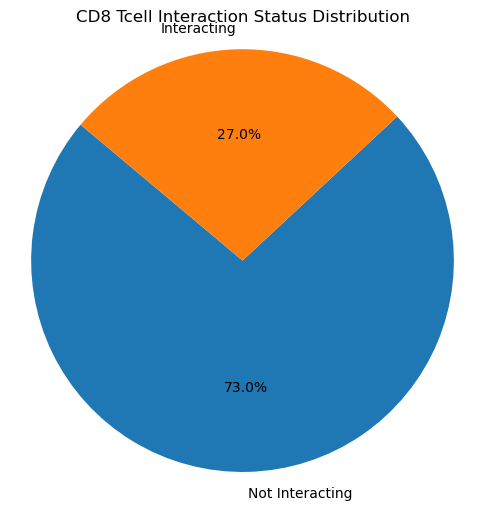

In [7]:
# def plot_interaction_status_pie_v2(interaction_matrix, title = "PMN Interaction Status Distribution"):
#     """
#     Plots a pie chart of PMN cell interaction status counts.
#     Parameters
#     ----------
#     interaction_matrix : pandas.DataFrame
#         The output DataFrame from `get_interaction_status()["Interaction Matrix"]` that contains 
#         the 'Interaction_Status' column.
#     title : str, optional
#         Title for the pie chart (default is "PMN Interaction Status Distribution").
#     Returns
#     -------
#     None
#         Displays the pie chart using matplotlib.
#     """
#     import matplotlib.pyplot as plt
    
#     # Count the frequency of each interaction status
#     status_counts = interaction_matrix['Interaction_Status'].value_counts()

#     # Plot pie chart
#     plt.figure(figsize=(6, 6))
#     plt.pie(
#         status_counts,
#         labels=status_counts.index,
#         autopct='%1.1f%%',
#         startangle=140
#     )
#     plt.title(title)
#     plt.axis('equal')  # Equal aspect ratio for a perfect circle
#     plt.show()

import my_functions

results2=my_functions.get_interaction_status_v2(adata,"c_1_19", 15, "CD8+T_cells", cell_type_1="Neutrophil")
my_functions.plot_interaction_status_pie_v2(results2["Interaction Matrix"],title = "CD8 Tcell Interaction Status Distribution")